# **Data Loading and Cleaning**

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [2]:
import os, sys, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

DATA_DIR = "/content"
OUTPUT_DIR = "clean_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data dir   : {os.path.abspath(DATA_DIR)}")
print(f"Output dir : {os.path.abspath(OUTPUT_DIR)}")

Data dir   : /content
Output dir : /content/clean_data


## Load & Raw Data Exploration

In [3]:
splits = ["train", "validation", "test"]
raw = {}
for s in splits:
    path = os.path.join(DATA_DIR, f"{s}.csv")
    raw[s] = pd.read_csv(path, on_bad_lines='skip', engine='python')
    print(f"[{s:>10}]  rows={len(raw[s]):>7,}  cols={list(raw[s].columns)}")

[     train]  rows= 92,211  cols=['id', 'article', 'highlights']
[validation]  rows= 13,368  cols=['id', 'article', 'highlights']
[      test]  rows= 11,490  cols=['id', 'article', 'highlights']


In [4]:
raw["train"].head(3)

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."


In [5]:
raw["train"].dtypes

,0
id,object
article,object
highlights,object


In [6]:
null_summary = pd.DataFrame({
    s: raw[s].isnull().sum() for s in splits
}).T
print("── Null counts ──")
print(null_summary)

── Null counts ──
            id  article  highlights
train        0        0           0
validation   0        0           0
test         0        0           0


In [7]:
for s in splits:
    dupes = raw[s].duplicated(subset=["id"]).sum()
    print(f"[{s}] duplicate IDs: {dupes}")

[train] duplicate IDs: 0
[validation] duplicate IDs: 0
[test] duplicate IDs: 0


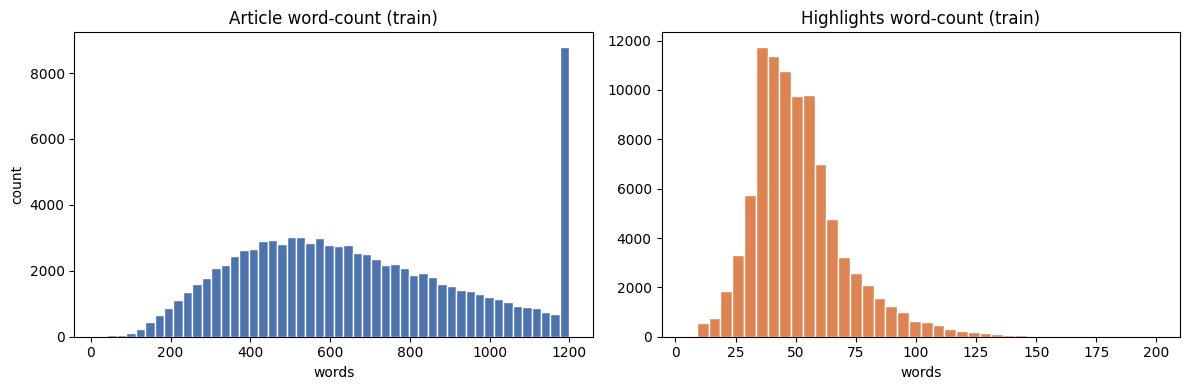

Article  — mean: 691  median: 630  max: 2226
Highlight— mean: 52  median: 48  max: 1296


In [8]:
train_art_wc  = raw["train"]["article"].dropna().str.split().str.len()
train_high_wc = raw["train"]["highlights"].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_art_wc.clip(upper=1200), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Article word-count (train)")
axes[0].set_xlabel("words"); axes[0].set_ylabel("count")

axes[1].hist(train_high_wc.clip(upper=200), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Highlights word-count (train)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "word_count_distribution.png"), dpi=120)
plt.show()
print(f"Article  — mean: {train_art_wc.mean():.0f}  median: {train_art_wc.median():.0f}  max: {train_art_wc.max()}")
print(f"Highlight— mean: {train_high_wc.mean():.0f}  median: {train_high_wc.median():.0f}  max: {train_high_wc.max()}")

## Data Cleaning
| Step | Action |
|------|--------|
| 1 | Drop rows where `article` **or** `highlights` is null |
| 2 | Strip leading/trailing whitespace |
| 3 | Drop empty strings after strip |
| 4 | Deduplicate by `id` |
| 5 | Filter by word-count thresholds |

In [9]:
MIN_ARTICLE_WORDS    = 30
MIN_HIGHLIGHTS_WORDS = 5
MAX_ARTICLE_WORDS    = 2_000

def clean_df(df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    tag = f"[{label}] " if label else ""
    orig = len(df)

    # 1. Drop nulls
    df = df.dropna(subset=["article", "highlights"])

    # 2. Strip whitespace
    df["article"]    = df["article"].str.strip()
    df["highlights"] = df["highlights"].str.strip()

    # 3. Drop empty strings
    df = df[(df["article"].str.len() > 0) & (df["highlights"].str.len() > 0)]

    # 4. Deduplicate
    df = df.drop_duplicates(subset=["id"])

    # 5. Word-count filter
    aw = df["article"].str.split().str.len()
    hw = df["highlights"].str.split().str.len()
    df = df[(aw >= MIN_ARTICLE_WORDS) & (aw <= MAX_ARTICLE_WORDS) & (hw >= MIN_HIGHLIGHTS_WORDS)]

    df = df.reset_index(drop=True)
    print(f"{tag}  {orig:>7,} → {len(df):>7,} rows  (removed {orig-len(df):,})")
    return df

clean = {}
print("Split          raw      clean    removed")
print("─" * 44)
for s in splits:
    clean[s] = clean_df(raw[s].copy(), label=s)


Split          raw      clean    removed
────────────────────────────────────────────
[train]    92,211 →  92,205 rows  (removed 6)
[validation]    13,368 →  13,368 rows  (removed 0)
[test]    11,490 →  11,490 rows  (removed 0)


## Verify Cleaned Data

In [10]:
verify = pd.DataFrame({
    s: {
        "rows":           len(clean[s]),
        "nulls_article":  clean[s]["article"].isnull().sum(),
        "nulls_highlights":clean[s]["highlights"].isnull().sum(),
        "duplicates":     clean[s].duplicated(subset=["id"]).sum(),
        "avg_art_words":  round(clean[s]["article"].str.split().str.len().mean(),1),
        "avg_high_words": round(clean[s]["highlights"].str.split().str.len().mean(),1),
    }
    for s in splits
}).T
verify

,rows,nulls_article,nulls_highlights,duplicates,avg_art_words,avg_high_words
train,92205.0,0.0,0.0,0.0,690.7,51.5
validation,13368.0,0.0,0.0,0.0,676.0,57.9
test,11490.0,0.0,0.0,0.0,683.5,55.0


## Visualization Of Cleaned Data

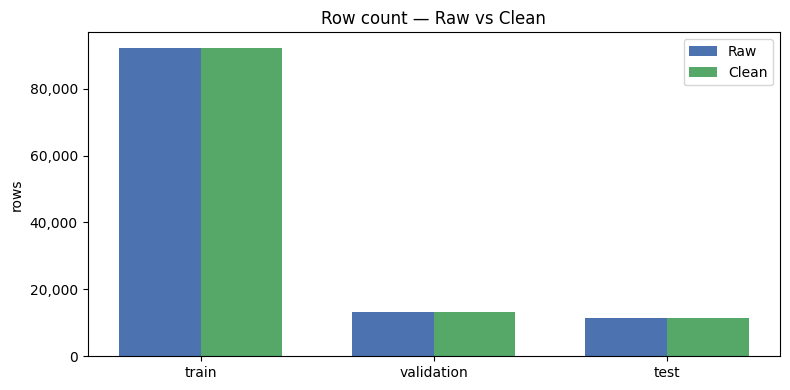

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(splits))
w = 0.35
ax.bar([i - w/2 for i in x], [len(raw[s]) for s in splits],  width=w, label="Raw",   color="#4C72B0")
ax.bar([i + w/2 for i in x], [len(clean[s]) for s in splits], width=w, label="Clean", color="#55A868")
ax.set_xticks(list(x)); ax.set_xticklabels(splits)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
ax.set_title("Row count — Raw vs Clean"); ax.set_ylabel("rows"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "raw_vs_clean.png"), dpi=120)
plt.show()


## Save Clean CSVs

In [12]:
for s in splits:
    out = os.path.join(OUTPUT_DIR, f"clean_{s}.csv")
    clean[s].to_csv(out, index=False)
    print(f"Saved → {out}  ({len(clean[s]):,} rows)")

Saved → clean_data/clean_train.csv  (92,205 rows)
Saved → clean_data/clean_validation.csv  (13,368 rows)
Saved → clean_data/clean_test.csv  (11,490 rows)


In [13]:
import pandas as pd

df = pd.read_csv("clean_data/clean_train.csv")
df.head()

,id,article,highlights
0,0001d1afc246a7964130f43ae940af6bc6c57f01,"By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATE...","Bishop John Folda, of North Dakota, is taking time off after being diagnosed..."
1,0002095e55fcbd3a2f366d9bf92a95433dc305ef,(CNN) -- Ralph Mata was an internal affairs lieutenant for the Miami-Dade Po...,Criminal complaint: Cop used his role to help cocaine traffickers .\nRalph M...
2,00027e965c8264c35cc1bc55556db388da82b07f,A drunk driver who killed a young woman in a head-on crash while checking hi...,"Craig Eccleston-Todd, 27, had drunk at least three pints before driving car ..."
3,0002c17436637c4fe1837c935c04de47adb18e9a,(CNN) -- With a breezy sweep of his pen President Vladimir Putin wrote a new...,Nina dos Santos says Europe must be ready to accept sanctions will hurt both...
4,0003ad6ef0c37534f80b55b4235108024b407f0b,Fleetwood are the only team still to have a 100% record in Sky Bet League On...,"Fleetwood top of League One after 2-0 win at Scunthorpe .\nPeterborough, Bri..."


# **Data Preprocessing**

In [14]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [15]:
def fast_sentence_split(text):
    if not isinstance(text, str):
        return []
    return [s.strip() for s in text.split('.') if len(s.strip()) > 5]

In [16]:
def preprocess_text_fast(text):
    if not isinstance(text, str):
        return {"sentences": [], "tokens": [], "clean_text": ""}

    # clean first
    clean_text = text.lower()
    clean_text = re.sub(r'[^a-zA-Z\s]', '', clean_text)

    # fast sentence split (original text)
    sentences = fast_sentence_split(text)
    sentences = [s.strip() for s in sentences if len(s.split()) > 5]

    # tokenize cleaned text
    words = word_tokenize(clean_text)

    # remove stopwords
    words = [w for w in words if w not in stop_words and w.strip() != ""]

    return {
        "sentences": sentences,
        "tokens": words,
        "clean_text": " ".join(words)
    }

In [17]:
sample = df["article"].iloc[0]

result = preprocess_text_fast(sample)

print(result["sentences"][:3])
print(result["clean_text"][:200])

['The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October', 'The state Health Department has issued an advisory of exposure for anyone who attended five churches and took communion', 'Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A']
associated press published est october updated est october bishop fargo catholic diocese north dakota exposed potentially hundreds church members fargo grand forks jamestown hepatitis virus late septe


In [18]:
from tqdm import tqdm
tqdm.pandas()

df = df.sample(5000, random_state=42)

df["processed"] = df["article"].progress_apply(preprocess_text_fast)

100%|██████████| 5000/5000 [00:11<00:00, 454.07it/s]


In [19]:

df["sentences"] = df["processed"].apply(lambda x: x["sentences"])
df["clean_text"] = df["processed"].apply(lambda x: x["clean_text"])

In [20]:
df.to_csv("clean_data/preprocessed_train_fast.csv", index=False)

In [21]:
print(df.shape)
print(df.columns)
print(df.head(1))

(5000, 6)
Index(['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text'], dtype='object')
                                             id  \
11897  21c0f75f77b8dab0396d1ba8f1d84e269c58f392   

                                                                               article  \
11897  The rise in antibiotic-resistant bacteria could lead to a future full of unt...   

                                                                            highlights  \
11897  Obama administration steps up efforts to combat problem of antibiotic resist...   

                                                                             processed  \
11897  {'sentences': ['The rise in antibiotic-resistant bacteria could lead to a fu...   

                                                                             sentences  \
11897  [The rise in antibiotic-resistant bacteria could lead to a future full of un...   

                                                                    

In [22]:
print(df["processed"].iloc[0])

{'sentences': ['The rise in antibiotic-resistant bacteria could lead to a future full of untreatable infections, experts have warned us for years', 'Now the Obama administration is stepping up its efforts to combat the rising problem of antibiotic resistance', 'The President signed an executive order Thursday establishing a new inter-agency task force charged with developing a national strategy to combat antibiotic-resistant bacteria', 'John Holdren, director of the White House Office of Science and Technology Policy and assistant to the President, said the problem is a serious challenge to public health and national security', '"We are clearly in a fight against', 'bacteria where no permanent treatment is possible', '" When you need antibiotics -- and when you don\'t', 'The task force will be co-chaired by the secretaries of Health & Human Services, the Department of Defense and the Department of Agriculture', 'The task force must submit its national action plan to the President by Fe

In [23]:
print(df["processed"].isnull().sum())

0


In [24]:
df.sample(3)[["sentences", "clean_text"]]

,sentences,clean_text
5860,"[Vauxhall has been on a roll this week, announcing hundreds of new jobs in B...",vauxhall roll week announcing hundreds new jobs britain ahead launch new ast...
27466,"[LONDON, England (CNN) -- The threat from terrorists using chemical, biologi...",london england cnn threat terrorists using chemical biological even nuclear ...
40034,[Sweden striker Zlatan Ibrahimovic last night scored the ‘greatest goal ever...,neil ashton matt barlow published est november updated est november sweden s...


# **Feature Extraction**

# Feature Engineering — Text Summarization System

**Step 2 of the NLP Pipeline**

This notebook builds on the preprocessed data (`preprocessed_train_fast.csv`) and performs:

| # | Task | Method |
|---|------|--------|
| 1 | **TF-IDF Features** | `TfidfVectorizer` → sentence scores |
| 2 | **Word2Vec Embeddings** | Train on corpus → sentence vectors |
| 3 | **Sentence Importance Score** | Combine TF-IDF + embedding similarity |
| 4 | **Save Features** | Persist for use in downstream summarization steps |

## 0 — Imports & Configuration

In [25]:
import warnings, os, ast
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Install gensim if not already installed
try:
    from gensim.models import Word2Vec
except ImportError:
    !pip install gensim
    from gensim.models import Word2Vec

# directories
DATA_DIR   = 'clean_data'
OUTPUT_DIR = 'features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅  All imports OK')
print(f'   Data directory   : {os.path.abspath(DATA_DIR)}')
print(f'   Feature directory: {os.path.abspath(OUTPUT_DIR)}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.1 MB/s eta 0:00:00
✅  All imports OK
   Data directory   : /content/clean_data
   Feature directory: /content/features


## 1 — Load Preprocessed Data

In [26]:
df = pd.read_csv(os.path.join(DATA_DIR, 'preprocessed_train_fast.csv'))

# parse 'sentences' column (stored as string repr of list)
def safe_parse_list(val):
    if isinstance(val, list):  return val
    try:                        return ast.literal_eval(val)
    except Exception:           return []

df['sentences'] = df['sentences'].apply(safe_parse_list)

# drop rows with empty sentences or clean_text
df = df[df['sentences'].map(len) > 0].reset_index(drop=True)
df = df[df['clean_text'].notna() & (df['clean_text'].str.strip() != '')].reset_index(drop=True)

print(f'Rows loaded : {len(df):,}')
print(f'Columns     : {list(df.columns)}')
df[['article', 'clean_text', 'sentences']].head(2)

Rows loaded : 5,000
Columns     : ['id', 'article', 'highlights', 'processed', 'sentences', 'clean_text']


,article,clean_text,sentences
0,The rise in antibiotic-resistant bacteria could lead to a future full of unt...,rise antibioticresistant bacteria could lead future full untreatable infecti...,[The rise in antibiotic-resistant bacteria could lead to a future full of un...
1,"Athens (CNN) -- After yet more financial turmoil and political wrangling, ci...",athens cnn yet financial turmoil political wrangling citizens greece readied...,"[Athens (CNN) -- After yet more financial turmoil and political wrangling, c..."


## 2 — Feature Extraction: TF-IDF

### 2.1  Corpus-level TF-IDF vocabulary
We fit a `TfidfVectorizer` on the full corpus of **cleaned texts**.  
This learns which words are **rare across articles** (high IDF) and therefore carry strong signal.

In [27]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20_000,   # keep top 20k vocabulary terms
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # apply log(1 + tf) smoothing
    min_df=2               # ignore terms appearing in < 2 docs
)

# Fit on cleaned text corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'TF-IDF matrix   : {tfidf_matrix.shape}  (docs × terms)')

Vocabulary size : 20,000
TF-IDF matrix   : (5000, 20000)  (docs × terms)


### 2.2  Sentence-level TF-IDF score

For each article we:
1. Split into individual sentences (already done in preprocessing).
2. Vectorize each sentence using the fitted vocabulary.
3. Compute the **mean TF-IDF weight** of the sentence as its importance score.

Higher score → sentence contains more distinctive / important keywords.

In [28]:
def score_sentences_tfidf(sentences, vectorizer):
    """
    Returns a list of TF-IDF importance scores, one per sentence.
    Score = mean of non-zero TF-IDF weights in that sentence.
    """
    if not sentences:
        return []

    # preprocess sentences the same way (lowercase, no punct)
    import re
    clean = [re.sub(r'[^a-zA-Z\s]', '', s.lower()) for s in sentences]

    try:
        mat = vectorizer.transform(clean)          # shape: (n_sents, vocab)
    except Exception:
        return [0.0] * len(sentences)

    # mean of non-zero entries per row
    scores = []
    for i in range(mat.shape[0]):
        row = mat.getrow(i)
        nz  = row.data
        scores.append(float(nz.mean()) if len(nz) > 0 else 0.0)

    return scores

# Apply to every article
from tqdm import tqdm
tqdm.pandas(desc='TF-IDF sentence scoring')

df['tfidf_scores'] = df['sentences'].progress_apply(
    lambda sents: score_sentences_tfidf(sents, tfidf_vectorizer)
)

# Sanity check on one article
idx = 0
print('\n── Sample article sentence scores ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['tfidf_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

TF-IDF sentence scoring: 100%|██████████| 5000/5000 [00:36<00:00, 135.14it/s]


── Sample article sentence scores ──
  [0.2688]  The rise in antibiotic-resistant bacteria could lead to a future full of untreat
  [0.3078]  Now the Obama administration is stepping up its efforts to combat the rising pro
  [0.2391]  The President signed an executive order Thursday establishing a new inter-agency
  [0.2048]  John Holdren, director of the White House Office of Science and Technology Polic
  [0.7065]  "We are clearly in a fight against


### 2.3  Visualise TF-IDF score distribution

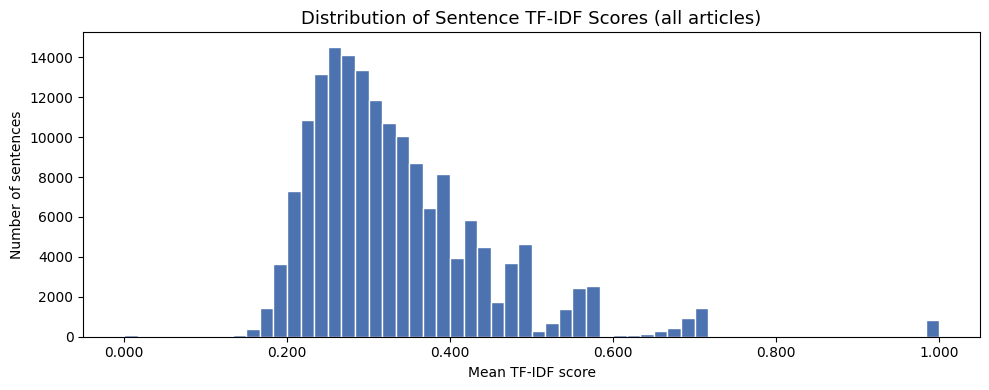

Score stats →  mean=0.3347  median=0.3084  max=1.0000


In [29]:
all_scores = [sc for row in df['tfidf_scores'] for sc in row]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=60, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Sentence TF-IDF Scores (all articles)', fontsize=13)
ax.set_xlabel('Mean TF-IDF score')
ax.set_ylabel('Number of sentences')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tfidf_score_distribution.png'), dpi=120)
plt.show()

print(f'Score stats →  mean={np.mean(all_scores):.4f}  '
      f'median={np.median(all_scores):.4f}  '
      f'max={np.max(all_scores):.4f}')

## 3 — Feature Extraction: Word2Vec Embeddings

### 3.1  Train Word2Vec on the corpus

We train a **Skip-gram Word2Vec** model on the tokenised texts.  
Each word gets a dense 100-dimensional vector that encodes **semantic meaning**.

In [30]:
# Build list of token lists from clean_text column
from nltk.tokenize import word_tokenize

print('Tokenising corpus for Word2Vec training …')
token_corpus = [text.split() for text in df['clean_text'] if isinstance(text, str)]

print(f'  Documents : {len(token_corpus):,}')
print(f'  Avg tokens: {np.mean([len(t) for t in token_corpus]):.1f}')

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=token_corpus,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=3,       # ignore words appearing < 3 times
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=5,
    seed=42
)

print(f'\n✅  Word2Vec trained')
print(f'   Vocabulary size : {len(w2v_model.wv):,} words')
print(f'   Embedding dims  : {w2v_model.vector_size}')

Tokenising corpus for Word2Vec training …
  Documents : 5,000
  Avg tokens: 379.3

✅  Word2Vec trained
   Vocabulary size : 37,845 words
   Embedding dims  : 100


### 3.2  Inspect the word vector space

A quick sanity-check — semantically similar words should appear close to each other.

In [31]:
probe_words = ['government', 'police', 'economy', 'president', 'report']

print('── Most similar words (Word2Vec) ──\n')
for word in probe_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"{w} ({s:.2f})" for w, s in similar])
        print(f'  {word:>12} → {similar_str}')
    else:
        print(f'  {word:>12} → (not in vocabulary)')

── Most similar words (Word2Vec) ──

    government → governments (0.77), libyas (0.71), coalition (0.71), parliaments (0.70), vetoed (0.70)
        police → officers (0.81), detectives (0.71), authorities (0.70), arrested (0.67), investigators (0.64)
       economy → austerity (0.81), recession (0.80), exports (0.80), economically (0.79), eurozone (0.78)
     president → barack (0.76), obama (0.72), biden (0.67), bush (0.66), vice (0.66)
        report → contributed (0.63), cnns (0.62), alkhshali (0.60), walsh (0.59), messia (0.59)


### 3.3  Sentence embeddings via mean-pooling

We represent each sentence as the **average Word2Vec vector** of its words.  
Words not in the vocabulary are skipped.

In [32]:
def sentence_to_vector(sentence: str, model: Word2Vec) -> np.ndarray:
    """
    Mean-pool Word2Vec vectors for all known words in the sentence.
    Returns a zero vector if no words are in the vocabulary.
    """
    import re
    tokens = re.sub(r'[^a-zA-Z\s]', '', sentence.lower()).split()
    vecs   = [model.wv[w] for w in tokens if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)          # shape: (vector_size,)
    return np.zeros(model.vector_size)


def get_sentence_embeddings(sentences, model):
    """Return a list of embedding vectors, one per sentence."""
    return [sentence_to_vector(s, model) for s in sentences]


# Apply — store as list of numpy arrays per document
tqdm.pandas(desc='Word2Vec sentence embeddings')

df['sentence_embeddings'] = df['sentences'].progress_apply(
    lambda sents: get_sentence_embeddings(sents, w2v_model)
)

# Show embedding for the first sentence of the first article
emb_sample = df['sentence_embeddings'].iloc[0][0]
print(f'Embedding shape : {emb_sample.shape}')
print(f'Sample values   : {emb_sample[:8].round(4)}')

Word2Vec sentence embeddings: 100%|██████████| 5000/5000 [00:08<00:00, 567.42it/s]

Embedding shape : (100,)
Sample values   : [ 0.1754 -0.0876 -0.1873  0.1741 -0.0772 -0.0838  0.0978  0.19  ]


### 3.4  Centroid similarity score

We compute the **document centroid** (mean of all sentence embeddings) and score each sentence by its **cosine similarity** to that centroid.  
Sentences that are *most representative* of the overall document get higher scores.

In [33]:
def centroid_similarity_scores(sentence_embeddings):
    """
    Compute cosine similarity of each sentence embedding to the document centroid.
    """
    if not sentence_embeddings:
        return []

    matrix   = np.vstack(sentence_embeddings)           # (n_sents, dim)
    centroid = matrix.mean(axis=0, keepdims=True)       # (1, dim)

    sims = cosine_similarity(matrix, centroid).flatten()  # (n_sents,)
    return sims.tolist()


tqdm.pandas(desc='Centroid similarity scoring')

df['embedding_scores'] = df['sentence_embeddings'].progress_apply(
    centroid_similarity_scores
)

# Sanity check
idx = 1
print('\n── Centroid similarity scores (sample) ──')
for s, sc in zip(df['sentences'].iloc[idx][:5], df['embedding_scores'].iloc[idx][:5]):
    print(f'  [{sc:.4f}]  {s[:80]}')

Centroid similarity scoring: 100%|██████████| 5000/5000 [00:02<00:00, 1746.21it/s]


── Centroid similarity scores (sample) ──
  [0.9701]  Athens (CNN) -- After yet more financial turmoil and political wrangling, citize
  [0.9157]  Two parties, New Democracy and Syriza, are considered to be front-runners going 
  [0.8714]  Campaigning has now ended but in the last official polls they were running neck-
  [0.8612]  No new polls are allowed in the 14 days before voting takes place
  [0.9625]  What will Greek elections mean for the country's future? Should a working majori


## 4 — Combined Sentence Importance Score

We merge the two signals into a single **importance score** per sentence:

$$\text{importance}(s_i) = \alpha \cdot \text{TF-IDF}(s_i) + (1-\alpha) \cdot \text{EmbeddingSim}(s_i)$$

- **TF-IDF score** → sentence contains key distinctive terms  
- **Embedding similarity** → sentence is representative of the document's topic

We normalise both signals to [0, 1] before combining.

In [34]:
ALPHA = 0.3   # weight for TF-IDF; (1-ALPHA) goes to embedding similarity

def normalize(scores):
    """Min-max normalise a list of scores to [0, 1]."""
    arr = np.array(scores, dtype=float)
    rng = arr.max() - arr.min()
    if rng == 0:
        return np.zeros_like(arr).tolist()
    return ((arr - arr.min()) / rng).tolist()


def combined_importance(tfidf_scores, embedding_scores, alpha=ALPHA):
    """
    Weighted combination of normalised TF-IDF and embedding-centroid scores.
    """
    n = len(tfidf_scores)
    if n == 0:
        return []

    t_norm = normalize(tfidf_scores)
    e_norm = normalize(embedding_scores) if embedding_scores else [0.0] * n

    return [alpha * t + (1 - alpha) * e
            for t, e in zip(t_norm, e_norm)]


df['importance_scores'] = df.apply(
    lambda row: combined_importance(row['tfidf_scores'], row['embedding_scores']),
    axis=1
)

print('✅  Combined importance scores computed')
print(f'   Alpha (TF-IDF weight)          : {ALPHA}')
print(f'   (1-Alpha) (Embedding weight)   : {1 - ALPHA}')

✅  Combined importance scores computed
   Alpha (TF-IDF weight)          : 0.3
   (1-Alpha) (Embedding weight)   : 0.7


## 5 — Demonstration: Top-scored Sentences per Article

Let's visually verify that our scoring picks **informative, high-value sentences**.

In [35]:
def get_top_sentences(sentences, importance_scores, top_n=3):
    """
    Return the top-N sentences by importance score,
    preserving their original document order.
    """
    if not sentences:
        return []

    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    # restore original order
    chosen_idx = sorted([i for i, _ in ranked])
    return [sentences[i] for i in chosen_idx]


for sample_idx in [0, 1, 2]:
    sents  = df['sentences'].iloc[sample_idx]
    scores = df['importance_scores'].iloc[sample_idx]
    top3   = get_top_sentences(sents, scores, top_n=3)

    print(f'\n{'='*70}')
    print(f'Article {sample_idx} | {len(sents)} sentences total')
    print(f'{'─'*70}')
    print('Original (first 200 chars):')
    print(' ', str(df['article'].iloc[sample_idx])[:200])
    print('\nTop-3 important sentences (feature-scored):')
    for i, s in enumerate(top3, 1):
        print(f'  [{i}] {s}')


Article 0 | 31 sentences total
──────────────────────────────────────────────────────────────────────
Original (first 200 chars):
  The rise in antibiotic-resistant bacteria could lead to a future full of untreatable infections, experts have warned us for years. Now the Obama administration is stepping up its efforts to combat the

Top-3 important sentences (feature-scored):
  [1] The order also established a Presidential Advisory Council made up of nongovernmental experts who will provide advice and recommendations to strengthen surveillance of infections, research new treatments and develop alternatives to antibiotics for use in agriculture
  [2] On Thursday, the administration released "National Strategy on Combating Antibiotic-Resistant Bacteria," a five-year plan to prevent and contain outbreaks and develop the next generation of tests, antibiotics and vaccines
  [3] In fact, a $20 million prize will be given to spur development of tests health care professionals can use to ident

## 6 — Per-Sentence Feature Table

Build an **exploded** sentence-level DataFrame for detailed inspection and downstream use.

In [36]:
rows = []
for doc_id, row in df.iterrows():
    for rank, (sent, tsc, esc, isc) in enumerate(
        zip(row['sentences'],
            row['tfidf_scores'],
            row['embedding_scores'],
            row['importance_scores'])):
        rows.append({
            'doc_id'          : doc_id,
            'sentence_rank'   : rank,
            'sentence'        : sent,
            'tfidf_score'     : round(tsc,  5),
            'embedding_score' : round(esc,  5),
            'importance_score': round(isc,  5),
        })

sent_df = pd.DataFrame(rows)
print(f'Sentence table shape: {sent_df.shape}')
sent_df.head(8)

Sentence table shape: (170870, 6)


,doc_id,sentence_rank,sentence,tfidf_score,embedding_score,importance_score
0,0,0,The rise in antibiotic-resistant bacteria could lead to a future full of unt...,0.26880,0.91856,0.60655
1,0,1,Now the Obama administration is stepping up its efforts to combat the rising...,0.30784,0.89979,0.56978
2,0,2,The President signed an executive order Thursday establishing a new inter-ag...,0.23914,0.92701,0.61609
3,0,3,"John Holdren, director of the White House Office of Science and Technology P...",0.20480,0.86881,0.41215
4,0,4,"""We are clearly in a fight against",0.70652,0.74153,0.30000
5,0,5,bacteria where no permanent treatment is possible,0.48588,0.84684,0.50536
6,0,6,""" When you need antibiotics -- and when you don't",0.51987,0.79197,0.35147
7,0,7,The task force will be co-chaired by the secretaries of Health & Human Servi...,0.29097,0.82752,0.33142


## 7 — Score Correlation Analysis

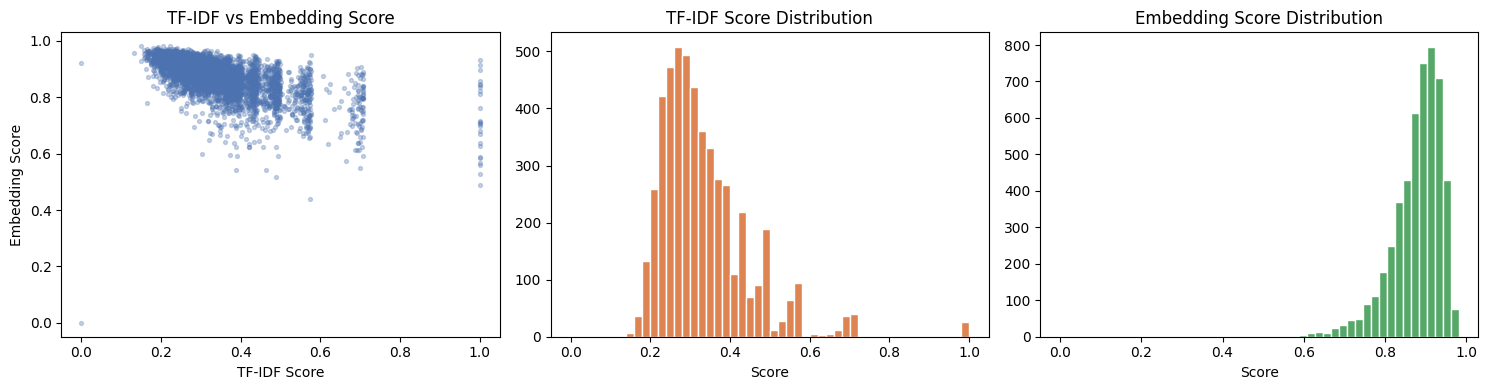


Correlation matrix:
                  tfidf_score  embedding_score  importance_score
tfidf_score             1.000           -0.619            -0.200
embedding_score        -0.619            1.000             0.714
importance_score       -0.200            0.714             1.000


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sample for speed
sample = sent_df.sample(min(5000, len(sent_df)), random_state=42)

axes[0].scatter(sample['tfidf_score'], sample['embedding_score'],
                alpha=0.3, s=8, color='#4C72B0')
axes[0].set_xlabel('TF-IDF Score');  axes[0].set_ylabel('Embedding Score')
axes[0].set_title('TF-IDF vs Embedding Score')

axes[1].hist(sample['tfidf_score'],     bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('TF-IDF Score Distribution');  axes[1].set_xlabel('Score')

axes[2].hist(sample['embedding_score'], bins=50, color='#55A868', edgecolor='white')
axes[2].set_title('Embedding Score Distribution');  axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_score_analysis.png'), dpi=120)
plt.show()

corr = sample[['tfidf_score', 'embedding_score', 'importance_score']].corr()
print('\nCorrelation matrix:')
print(corr.round(3))

## 8 — Save Features

In [38]:
import pickle, json

# 8a. Document-level features (with lists) → pickle
doc_features = df[['article', 'highlights', 'clean_text',
                    'sentences', 'tfidf_scores',
                    'embedding_scores', 'importance_scores']].copy()

doc_features.to_pickle(os.path.join(OUTPUT_DIR, 'doc_features.pkl'))
print('✅  Saved  →  features/doc_features.pkl')

# 8b. Sentence-level feature table → CSV
sent_df.to_csv(os.path.join(OUTPUT_DIR, 'sentence_features.csv'), index=False)
print('✅  Saved  →  features/sentence_features.csv')

# 8c. TF-IDF vectorizer → pickle
with open(os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('✅  Saved  →  features/tfidf_vectorizer.pkl')

# 8d. Word2Vec model
w2v_model.save(os.path.join(OUTPUT_DIR, 'word2vec.model'))
print('✅  Saved  →  features/word2vec.model')

# 8e. Config metadata
config = {
    'alpha'            : ALPHA,
    'tfidf_max_features': 20_000,
    'tfidf_ngram_range': [1, 2],
    'w2v_vector_size'  : w2v_model.vector_size,
    'w2v_window'       : 5,
    'w2v_min_count'    : 3,
    'w2v_sg'           : 1,
    'docs_processed'   : len(df)
}
with open(os.path.join(OUTPUT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('✅  Saved  →  features/feature_config.json')

✅  Saved  →  features/doc_features.pkl
✅  Saved  →  features/sentence_features.csv
✅  Saved  →  features/tfidf_vectorizer.pkl
✅  Saved  →  features/word2vec.model
✅  Saved  →  features/feature_config.json


## 9 — Summary

| Feature | Description | Saved as |
|---------|-------------|----------|
| **TF-IDF matrix** | Corpus-level term weights (20k vocab, 1–2 grams) | `tfidf_vectorizer.pkl` |
| **TF-IDF sentence score** | Mean TF-IDF weight per sentence | inside `doc_features.pkl` |
| **Word2Vec embeddings** | 100-dim skip-gram trained on corpus | `word2vec.model` |
| **Embedding similarity** | Cosine similarity to document centroid | inside `doc_features.pkl` |
| **Combined importance** | α·TF-IDF + (1-α)·EmbSim, both normalised | `doc_features.pkl` & `sentence_features.csv` |


# **BaseLine Model**

In [39]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [77]:
def summarize_baseline(sentences, importance_scores, top_n=3, show_rank=True):
    if not sentences:
        return ""

    #sort by scores
    ranked = sorted(
        enumerate(importance_scores),
        key=lambda x:x[1],
        reverse=True

    )[:top_n]

    if show_rank:
      print("\n Sentences ranking")

      for rank,(idx,score) in enumerate(ranked,1):
          print(f"Rank {rank}")
          print(f"Score :{score:.4f}")
          print(f"Sentence :{sentences[idx]}")
          print("-"*70)




    indices= sorted([i for i,_ in ranked])  #to order them like their order in dovument
    bs_summary=" ".join([sentences[i] for i in indices])
    return bs_summary

In [82]:
#Show the high ranked senntences
row=df.iloc[0]
sentences=row["sentences"]
importance_scores=row["importance_scores"]

bs_summary = summarize_baseline(
    sentences,
    importance_scores,
    top_n=3
)

print(bs_summary)


 Sentences ranking
Rank 1
Score :0.7100
Sentence :On Thursday, the administration released "National Strategy on Combating Antibiotic-Resistant Bacteria," a five-year plan to prevent and contain outbreaks and develop the next generation of tests, antibiotics and vaccines
----------------------------------------------------------------------
Rank 2
Score :0.7055
Sentence :The order also established a Presidential Advisory Council made up of nongovernmental experts who will provide advice and recommendations to strengthen surveillance of infections, research new treatments and develop alternatives to antibiotics for use in agriculture
----------------------------------------------------------------------
Rank 3
Score :0.6741
Sentence :In fact, a $20 million prize will be given to spur development of tests health care professionals can use to identify highly resistant bacterial infections
----------------------------------------------------------------------
The order also established a 

In [60]:
df["baseline_summary"]= df.apply(
    lambda row:summarize_baseline(
        row["sentences"],
        row["importance_scores"],
        top_n=3

    ),
    axis=1

)

In [61]:
#to check the difference in size of baseline and improved one

df["compression_baseline"]=df.apply(
    lambda r:len(r["baseline_summary"].split()) /len(r["article"].split()),
    axis=1
)


print("Baseline avg compression:",df["compression_baseline"].mean())


Baseline avg compression: 0.12382530103582612


In [67]:
!pip install tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

tqdm.pandas()

model=SentenceTransformer('all-MiniLM-L6-v2')

def semantic_score(row):

    #change to vectors
    orig=model.encode(row["article"])
    summary=model.encode(row["baseline_summary"])
    return cosine_similarity([orig],[summary])[0][0]

df["semantic_score"]=df.progress_apply(semantic_score,axis=1)
print("Semantic avg:",df["semantic_score"].mean())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 5000/5000 [03:53<00:00, 21.42it/s]

Semantic avg: 0.69158506


In [68]:
#test
def test_baseline_sample(df,index=0):
    row =df.iloc[index]
    print(f"Article(first 400 chars):\n{row['article'][:400]}...\n")

    print("Basline Summary:\n")
    print(row["baseline_summary"])

    print(f"Compression:{row['compression_baseline']:.4f}")
    print(f"Semantic Similarity:{row['semantic_score']:.4f}")


In [69]:
import random
for i in random.sample(range(len(df)),3):
     test_baseline_sample(df,i)

Article(first 400 chars):
By . Simon Tomlinson . A Satanist nurse who posted pictures of herself next to dead and dying pensioners at the care home where she worked has been fined £800 by a Swiss court. Blaze Binder published the photos next to messages saying she was the 'soul thief' and 'Hail Satan'. She asked her 2,000 friends on Facebook, where she goes by the name Ghostinthedark Satania Blaze, to guess if the pensione...

Basline Summary:

She asked her 2,000 friends on Facebook, where she goes by the name Ghostinthedark Satania Blaze, to guess if the pensioners were dead or alive Sickening: Satanist nurse Blaze Binder smiles next to a dying pensioner at the Swiss care home where she worked in an image which she then posted on Facebook ' Adding to the scandal were additional pictures on the internet of the Filipino as a 'dominatrix', her other profession
Compression:0.1364
Semantic Similarity:0.8074
Article(first 400 chars):
They were issued to US soldiers by the military at the s

### Save Baseline Model PKI and model



In [54]:
import pickle
import os

try:
  from gensim.models import Word2Vec
except ImportError:
  !pip install gensim
  from gensim.models import Word2Vec

OUTPUT_DIR='features'

#load tf-idf vectorizer
with open(os.path.join(OUTPUT_DIR,'tfidf_vectorizer.pkl'),'rb') as f:
    loaded_tfidf_vectorizer=pickle.load(f)


#load word2vec model
loaded_w2v_model=Word2Vec.load(os.path.join(OUTPUT_DIR,'word2vec.model'))

print("loaded TF-IDF vectorizer and Word2Vec model")

loaded TF-IDF vectorizer and Word2Vec model


In [55]:
#try sample with this loaded models

if 'df' not in locals():
  print("df not found ,ensure previous data loaded.")
  sample_article_text="This is a sample article for demonstration. It has multiple sentences. We will try to summarize it. The TF-IDF and Word2Vec models are used to determine sentence importance. This helps in extracting key sentences."

  sample_sentences=[s.strip() for s in sample_article_text.split('.') if len (s.strip())>5]
  sample_clean_text=' '.join(nltk.word_tokenize(re.sub(r'[^a-zA-Z\s]','',sample_article_text.lower())))

else:
  sample_row=df.iloc[0]
  sample_article_text=sample_row['article']
  sample_sentences=sample_row['sentences']
  sample_clean_text=sample_row['clean_text']


#tf-idf
tfidf_scores_new=score_sentences_tfidf(sample_sentences,loaded_tfidf_vectorizer)

#w2v &centroid similarity
sentence_embeddings_new=get_sentence_embeddings(sample_sentences,loaded_w2v_model)
embedding_scores_new=centroid_similarity_scores(sentence_embeddings_new)

#combined scores
importance_scores_new=combined_importance(tfidf_scores_new,embedding_scores_new,alpha=ALPHA)


#summary
baseline_summary_new=summarize_baseline(sample_sentences,importance_scores_new,top_n=3)

print("\n Sample article(first 500 letters) ")
print(sample_article_text[:500],"...") #to fill in when no space
print("\n Generated Baseline summary")
print(baseline_summary_new)



 Sample article(first 500 letters) 
The rise in antibiotic-resistant bacteria could lead to a future full of untreatable infections, experts have warned us for years. Now the Obama administration is stepping up its efforts to combat the rising problem of antibiotic resistance. The President signed an executive order Thursday establishing a new inter-agency task force charged with developing a national strategy to combat antibiotic-resistant bacteria. Dr. John Holdren, director of the White House Office of Science and Technology Po ...

 Generated Baseline summary
The order also established a Presidential Advisory Council made up of nongovernmental experts who will provide advice and recommendations to strengthen surveillance of infections, research new treatments and develop alternatives to antibiotics for use in agriculture On Thursday, the administration released "National Strategy on Combating Antibiotic-Resistant Bacteria," a five-year plan to prevent and contain outbreaks and dev

In [56]:

MODEL_DIR="saved_models"
os.makedirs(MODEL_DIR,exist_ok=True)

with open(os.path.join(MODEL_DIR,"tfidf_vectorizer.pkl"),"wb") as f:
    pickle.dump(tfidf_vectorizer,f)

print("TF-IDF vectorizer saved")

TF-IDF vectorizer saved


# **Advanced Model: Transformer Summarizer**

For low-memory execution, the default model is `sshleifer/distilbart-cnn-6-6` instead of `facebook/bart-large-cnn`.

## 1 — Install/Import Requirements



In [49]:
# Colab install command if needed:
# !pip install -q transformers sentencepiece accelerate

import os
import re
import math
import gc
import pandas as pd
import torch

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    files = None
    IN_COLAB = False

try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
except ImportError as exc:
    raise ImportError(
        "Install Transformer dependencies first: pip install transformers torch sentencepiece accelerate"
    ) from exc


## 2 — Load Articles for Standalone Advanced Run




In [ ]:
# upload a CSV when prompted.
CSV_PATH = None

if CSV_PATH is None and IN_COLAB:
    uploaded = files.upload()
    CSV_PATH = next(iter(uploaded))

if CSV_PATH is None:
    CSV_PATH = "train.csv"

advanced_input_df = pd.read_csv(CSV_PATH)

if "article" not in advanced_input_df.columns:
    raise ValueError("The uploaded CSV must contain an 'article' column.")

advanced_input_df = advanced_input_df.dropna(subset=["article"]).copy()
if "highlights" not in advanced_input_df.columns:
    advanced_input_df["highlights"] = ""

print(f"Loaded {len(advanced_input_df):,} rows for the standalone advanced model")
print(advanced_input_df[["article", "highlights"]].head(1))


## 3 — Load the Pretrained Transformer

DistilBART has an encoder-decoder architecture: the encoder reads the article, and the decoder generates the summary token by token. GPU is used automatically when available.

In [ ]:
MODEL_NAME = "sshleifer/distilbart-cnn-6-6"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_NAME} on {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
transformer_model.eval()

# Keep memory pressure lower before inference.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## 4 — Handle Long Articles

Transformer models have a maximum input length. BART usually accepts up to 1024 tokens, so long articles are split into sentence-based chunks. Each chunk is summarized, then the chunk summaries are optionally summarized again into one final output.

In [ ]:
def sentence_split_for_transformer(text):
    """Split text into sentences while reusing the preprocessing splitter when available."""
    if not isinstance(text, str) or not text.strip():
        return []
    if "fast_sentence_split" in globals():
        return fast_sentence_split(text)
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def chunk_text_by_tokens(text, tokenizer, max_input_tokens=900):
    """Create chunks that fit the model while trying to keep sentence boundaries."""
    sentences = sentence_split_for_transformer(text)
    chunks = []
    current = []
    current_tokens = 0

    for sentence in sentences:
        sentence_tokens = len(tokenizer.encode(sentence, add_special_tokens=False))

        if sentence_tokens > max_input_tokens:
            if current:
                chunks.append(" ".join(current))
                current, current_tokens = [], 0
            token_ids = tokenizer.encode(sentence, add_special_tokens=False)
            for start in range(0, len(token_ids), max_input_tokens):
                chunks.append(tokenizer.decode(token_ids[start:start + max_input_tokens], skip_special_tokens=True))
            continue

        if current and current_tokens + sentence_tokens > max_input_tokens:
            chunks.append(" ".join(current))
            current = [sentence]
            current_tokens = sentence_tokens
        else:
            current.append(sentence)
            current_tokens += sentence_tokens

    if current:
        chunks.append(" ".join(current))

    return chunks or [text[:4000]]

## 5 — Generate Abstractive Summaries

`max_length` controls the longest summary, `min_length` prevents extremely short summaries, and `num_beams` improves generation quality by searching multiple candidate summaries.

In [ ]:
def summarize_with_bart(
    text,
    max_input_tokens=512,
    max_length=80,
    min_length=20,
    num_beams=1,
    length_penalty=1.5,
):
    """Summarize one article with BART, including long-text chunk handling."""
    if not isinstance(text, str) or not text.strip():
        return ""

    chunks = chunk_text_by_tokens(text, tokenizer, max_input_tokens=max_input_tokens)
    chunk_summaries = []

    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            return_tensors="pt",
            max_length=max_input_tokens,
            truncation=True,
        ).to(DEVICE)

        with torch.no_grad():
            summary_ids = transformer_model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        chunk_summaries.append(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

    combined_summary = " ".join(chunk_summaries)

    if len(chunks) == 1:
        return combined_summary

    combined_tokens = len(tokenizer.encode(combined_summary, add_special_tokens=False))
    if combined_tokens <= max_input_tokens:
        inputs = tokenizer(combined_summary, return_tensors="pt", truncation=True, max_length=max_input_tokens).to(DEVICE)
        with torch.no_grad():
            final_ids = transformer_model.generate(
                **inputs,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                length_penalty=length_penalty,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )
        return tokenizer.decode(final_ids[0], skip_special_tokens=True)

    return combined_summary

## 6 — Run the Advanced Model on a Sample

Transformer inference is slower than TF-IDF. Start with a small sample, inspect quality, then increase `ADVANCED_SAMPLE_SIZE` when the setup is stable.

In [ ]:
ADVANCED_SAMPLE_SIZE = 10
advanced_df = advanced_input_df.head(ADVANCED_SAMPLE_SIZE).copy()

advanced_df["advanced_summary"] = advanced_df["article"].apply(summarize_with_bart)
advanced_df["advanced_compression"] = advanced_df.apply(
    lambda r: len(r["advanced_summary"].split()) / max(len(r["article"].split()), 1),
    axis=1,
)

display_columns = ["article", "highlights", "advanced_summary", "advanced_compression"]
if "baseline_summary" in advanced_df.columns:
    display_columns.insert(2, "baseline_summary")

advanced_df[display_columns].head()


## 7 — Compare Baseline vs Transformer

Use this view to explain the difference in your report: the baseline copies important sentences, while the Transformer can paraphrase and combine ideas into a shorter generated summary.

In [ ]:
def show_advanced_example(dataframe, index=0):
    row = dataframe.iloc[index]
    print("ARTICLE:")
    print(row["article"], "...\n")

    print("REFERENCE HIGHLIGHTS:")
    print(row["highlights"], "\n")

    if "baseline_summary" in row:
        print("TF-IDF BASELINE SUMMARY:")
        print(row["baseline_summary"], "\n")

    print("TRANSFORMER ADVANCED SUMMARY:")
    print(row["advanced_summary"])

show_advanced_example(advanced_df, 0)

## 8 — Save Advanced Outputs

The saved CSV can be used by the Evaluation Engineer to compute ROUGE and build comparison tables.

In [ ]:
os.makedirs("clean_data", exist_ok=True)
advanced_output_path = "clean_data/advanced_summaries_sample.csv"

save_columns = ["article", "highlights", "advanced_summary", "advanced_compression"]
if "baseline_summary" in advanced_df.columns:
    save_columns.insert(2, "baseline_summary")

advanced_df[save_columns].to_csv(
    advanced_output_path,
    index=False,
)
print(f"Saved advanced summaries to {advanced_output_path}")


## 9 — Report Notes for the Advanced Method

the advanced model as an abstractive Transformer summarizer based on BART. articles are split into token-limited chunks, each chunk is summarized, and multi-chunk outputs are summarized again. Important parameters to report are `max_input_tokens`, `max_length`, `min_length`, `num_beams`, and `length_penalty`.